<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/kfoldbin.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [77]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso: Análisis de datos                              #
# Tópico: Validación cruzada en clasificación binaria   #
#########################################################

Carga bibliotecas necesarias

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.model_selection import KFold
from scipy.stats import rankdata

Instala y carga la biblioteca de LIBSVM

In [79]:
# https://github.com/cjlin1/libsvm
!pip install -q -U libsvm-official
from libsvm.svmutil import *

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [80]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Solo se utilizan dos clases

In [81]:
idx = (Y == 1) | (Y == 2) # Selecciona clases versicolor y virginica
X = X[idx.ravel(), :]
Y = Y[idx.ravel(), :]
Y[Y==2] = -1  # Asegura etiquetas -1 y +1
labels = iris.target_names[[1,2]] # Etiquetas de clase

Funciones para el cálculo de índices de desempeño para clasificación binaria

In [82]:
def AUC(Yp, Ytrue):
    # Ensure inputs are numpy arrays
    Yp = np.asarray(Yp)
    Ytrue = np.asarray(Ytrue)
    xi = Yp[Ytrue==+1];
    xj = Yp[Ytrue==-1];
    n0 = xi.shape[0];
    n1 = xj.shape[0];
    r = rankdata(np.concatenate([xi, xj]));
    s0 = np.sum(r[0:n0]);
    z = (s0-(n0*(n0+1)/2))/(n0*n1);
    return z

def binclassperf(Yt, Yp, Sp):
    Yt = np.asarray(Yt)
    Yp = np.asarray(Yp)
    Sp = np.asarray(Sp)
    pL = Yt == +1;
    nL = Yt == -1;
    TP = np.sum(Yp[pL] == +1)
    TN = np.sum(Yp[nL] == -1)
    FP = np.sum(Yp[nL] == +1)
    FN = np.sum(Yp[pL] == -1)
    C   = np.array([[TP, FN], [FP, TN]]) # Confusion matrix
    ACC = (TP+TN)/(TP+TN+FP+FN) # Accuracy
    MCC = ((TP*TN)-(FP*FN))/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) # Matthews correlation coefficient
    PRE = TP/(TP+FP) # precision
    SEN = TP/(TP+FN) # sensitivity or recall
    SPE = TN/(FP+TN) # specificity
    BAC = 0.5*(SEN+SPE) # balanced accuracy
    F1s = (2*TP)/(2*TP+FP+FN) # F1 score
    Z   = AUC(Sp,Yt)
    Out = np.array([MCC,ACC,PRE,SEN,SPE,F1s,BAC,Z]);
    return Out, C

Divide el conjunto de datos usando validación cruzada con 5 pliegues

In [83]:
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

Itera sobre cada pliegue haciendo entrenamiento y prueba

In [84]:
# Parámetros de SVM
gamma = 0.01
C = 100
opt = '-q -s 0 -t 2 -c %f -g %f' % (C, gamma)

cm = np.zeros((2,2)) # Matriz de confusión
res = np.zeros(8) # Vector de resultados
Y_pred = np.array([])
Y_true = np.array([])
for train_idx, test_idx in kf.split(X):
    # Divide en entrenamiento y prueba
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    # Normaliza los conjuntos de datos
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    # Entrena SVM
    model = svm_train(Y_train.ravel().tolist(), X_train, opt)
    # Clasifica con SVM
    Y_temp, _, Y_scr = svm_predict(Y_test.ravel().tolist(), X_test, model, '-q')
    # Evalua desempeño de clasificación
    aux1, aux2 = binclassperf(Y_test.ravel(), Y_temp, np.array(Y_scr).ravel())
    res += aux1
    cm += aux2
    # Concatena predicciones
    Y_pred = np.concatenate((Y_pred, Y_temp))
    Y_true = np.concatenate((Y_true, Y_test.ravel()))
res = res/K # Promedio

#Imprime resultados
indice = ['MCC', 'ACC', 'PRE', 'SEN', 'SPE', 'F1s', 'BAC', 'AUC']
for i in range(len(res)):
    print('%s: %0.3f\n' % (indice[i], res[i]), end='')

MCC: 0.906
ACC: 0.950
PRE: 1.000
SEN: 0.911
SPE: 1.000
F1s: 0.951
BAC: 0.955
AUC: 0.990


Visualiza matriz de confusión

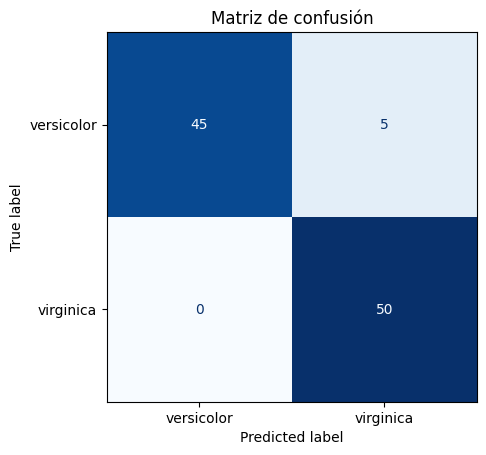

In [85]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

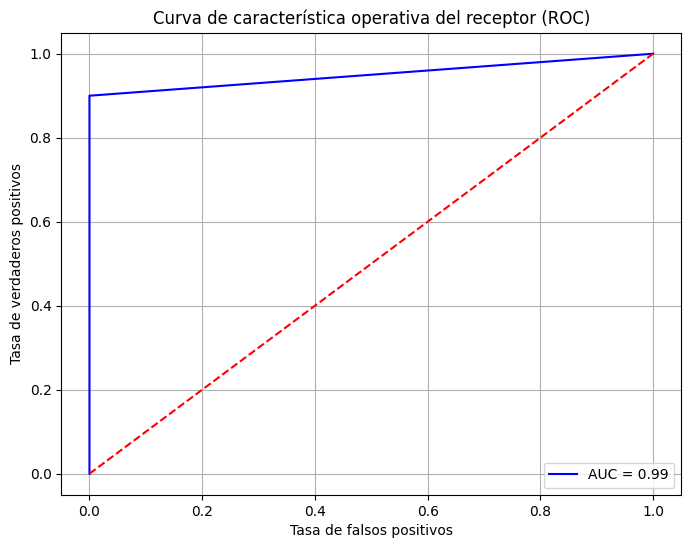

In [86]:
# Calcula la curva ROC
fpr, tpr, thresholds = roc_curve(Y_true, Y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {res[7]:.2f}') # Changed res[8] to res[7]
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # No skill line
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva de característica operativa del receptor (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()